In [37]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Input, Dense, Reshape, Conv1DTranspose, BatchNormalization, Conv1D, LeakyReLU, Flatten, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.losses import mse
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import backend as K

In [38]:
from typing import List
from scipy.signal import butter, sosfiltfilt
import pandas as pd
import os
import numpy as np
from scipy.stats import zscore
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")



class PreprocessingEEG:
    def __init__(self, 
                 eeg_paths:List[str], 
                 lowcut=0.1, 
                 highcut=40, 
                 fs=250.0, 
                 order=4,
                 artifact_removal_zscore_amplitude=5,
                 artifact_removal_p2p=200,
                 segment_duration=50,
                 overlap=0.5
    ):
        """
        Args:                               
            eeg_paths (List[str]): Paths to EEG data files.
            lowcut (float): Lower cutoff frequency for bandpass filter.
            highcut (float): Upper cutoff frequency for bandpass filter.
            fs (float): Sampling frequency of the EEG data.
            order (int): Order of the Butterworth filter.
            artifact_removal_zscore_amplitude (float): Z-score threshold for artifact removal.
        """
        self.eeg_paths = eeg_paths
        self.lowcut = lowcut
        self.highcut = highcut
        self.fs = fs
        self.order = order
        self.artifact_removal_zscore_amplitude = artifact_removal_zscore_amplitude
        self.artifact_removal_p2p = artifact_removal_p2p
        self.segment_duration = segment_duration
        self.overlap = overlap

        self.clean_dfs = []
        self.sampling_datas_detail = []

    def bandpass_filter_scipy(self, data, highcut=None, lowcut=None, fs=None, order=None):
        """
        Applies a zero-phase Butterworth bandpass filter to EEG data.

        Args:
            data (np.array): 1D or 2D EEG signal (time series). 
                            If 2D, shape should be (n_channels, n_samples).
            lowcut (float): Lower cutoff frequency (Hz).
            highcut (float): Upper cutoff frequency (Hz).
            fs (float): Sampling frequency (Hz).
            order (int): Filter order (default=5).

        Returns:
            np.array: Bandpass-filtered EEG signal, same shape as input.
        """
        if lowcut is not None:
            self.lowcut = lowcut
        if highcut is not None:
            self.highcut = highcut  
        if fs is not None: 
            self.fs = fs
        if order is not None:
            self.order = order     
        print(f"[DEBUG] lowcut={self.lowcut}, highcut={self.highcut}, fs={self.fs}, order={self.order}")

        sos = butter(self.order, [self.lowcut, self.highcut], btype='band', fs=self.fs, output='sos')
        filtered = sosfiltfilt(sos, data, axis=-1)  # filter tiap channel
        return filtered
  
    def reject_epoch(self, epoch):
        # Peak-to-peak
        ptp = np.ptp(epoch)
        zscore_epoch = zscore(epoch)
        abs_zscore = np.abs(zscore_epoch)
        print(f"ptp: {ptp}, zscore abs: {np.max(abs_zscore)}")
        if ptp > self.artifact_removal_p2p:  # 200 µV, ubah ke Volt kalau datanya µV
            print("Rejecting due to peak-to-peak")
            return True
        
        # Z-score
        if np.any(abs_zscore) > self.artifact_removal_zscore_amplitude:
            print("Rejecting due to Z-score")
            return True
        
        return False
    
    def segment_signal(self,data):
        """
        Membagi sinyal menjadi segment dengan overlap.
        
        Args:
            data (np.array): 1D (n_samples) atau 2D (n_channels, n_samples).
            fs (int): Sampling rate dalam Hz.
            segment_duration (float): Panjang segmen dalam detik.
            overlap (float): Proporsi overlap (0–1), default 0.5 = 50%.
        
        Returns:
            np.array: Segment dengan shape (n_segments, n_channels, n_samples_per_segment).
        """
        print(f"Segmenting signal with shape: {data.shape}")
        if data.ndim == 1:
            data = data[np.newaxis, :]  # ubah ke (1, n_samples)

        # --- deteksi orientasi ---
        # asumsi: axis dengan panjang terbesar = waktu (samples)
        if data.shape[0] > data.shape[1]:
            # berarti (n_samples, n_channels), transpose jadi (n_channels, n_samples)
            data = data.T
            print("Transposed data to ensure (n_channels, n_samples)")
        print(f"After ensuring 2D, data shape: {data.shape}")
        n_channels, n_samples = data.shape
        seg_len = int(self.segment_duration * self.fs)
        step = int(seg_len * (1 - self.overlap))
        print(f"Segment length (samples): {seg_len}, Step size (samples): {step}")
        segments = []
        for start in range(0, n_samples - seg_len + 1, step):
            end = start + seg_len
            print(f"Creating segment from {start} to {end}")
            segments.append(data[:, start:end])
        print(f"Total segments created: {len(segments)}")
        return np.array(segments)  # shape = (n_segments, n_channels, seg_len)
    
    def listing_eeg_files(self,all_txt=True):
        list_data = []
        for root_path in self.eeg_paths:
            name_patient = os.listdir(root_path)
            for dir_patient in name_patient:
                label = "NORMAL" if "NORMAL" in root_path else "ASD"
                print(f"Processing patient: {dir_patient} with label: {label}")
                dir_patient_path = os.path.join(root_path, dir_patient)

                if os.path.isdir(dir_patient_path):
                    session_names = os.listdir(dir_patient_path)
                    if len(session_names) != 2 and all_txt==True:
                        print(f"Patient: {dir_patient}, Sessions: {session_names} skip")
                        continue
                    data = []
                    for session in session_names:
                        session_path = os.path.join(dir_patient_path, session)
                        if os.path.isdir(session_path):
                            txt_files = [f for f in os.listdir(session_path) if f.endswith(".txt")]
                            if len(txt_files) == 0:
                                print(f"No .txt files found in {session_path}, skip")
                                continue
                            if not all_txt:
                                list_path_txt = []
                                for txt_file in txt_files:
                                    list_path_txt.append(os.path.join(session_path, txt_file))
                                data.append(list_path_txt)
                            else:
                                data.append(os.path.join(session_path, txt_files[-1]))
                    if len(data) != 2 and all_txt==True:
                        print(f"Patient: {dir_patient} does not have 2 sessions, skip")
                        continue
                     
                    list_data.append((dir_patient,label, data))
        return list_data

    def load_and_preprocess(self,sampling=False,out_path=None,reject_epoch=True):
        list_data = self.listing_eeg_files()

        print(f"Total patients with 2 sessions: {len(list_data)}")

        labels = []
        datas = []
        clean_datasets = []
        total_epochs_rejected = 0
        total_epochs_accepted = 0
        data_status = []
        count_segments = defaultdict(int)

        for patient_idx, (patient_name,label, data_paths) in tqdm(enumerate(list_data)):
            print(f"Processing patient: {patient_name}")
            txt_1_path = data_paths[0]
            txt_2_path = data_paths[1]

            df1 = pd.read_csv(txt_1_path, comment="%", header=0)
            exg_cols_df_1 = [col for col in df1.columns if "EXG Channel" in col]
            exg_data_1 = df1[exg_cols_df_1]
            df2 = pd.read_csv(txt_2_path, comment="%", header=0)
            exg_cols_df_2 = [col for col in df2.columns if "EXG Channel" in col]
            exg_data_2 = df2[exg_cols_df_2]

            ch_names = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4",
                    "O1","O2","F7","F8","T3","T4","T5","T6"]

            df_combine = pd.concat([exg_data_1, exg_data_2], axis=1)
            df_combine.columns = ch_names
           
            df_combine = df_combine.dropna().reset_index(drop=True)
            clean_data_combine_filtered = df_combine.dropna().reset_index(drop=True)
            print(f"After filtering drop na, data shape: {clean_data_combine_filtered.shape}")
            self.clean_dfs.append((patient_name,label, clean_data_combine_filtered))

            if sampling:
                epochs = self.segment_signal(clean_data_combine_filtered.values)
                epoch_accepted = 0
                print(f"Segmented into {len(epochs)} epochs of shape {epochs.shape[1:]} for patient {patient_name}")
                for idx, epoch in enumerate(epochs):
                    # apply bandpass filter to each channel
                    print(epoch.shape)
                    epoch = self.bandpass_filter_scipy(epoch)
                    print(f"After filtering bandpass_filter_scipy, data shape: {epoch.shape}")
                    epoch_df = pd.DataFrame(epoch.T, columns=ch_names)
                    count_segments[patient_name] += 1
                    if out_path:
                        out_segment_path = os.path.join(out_path,'segments')
                        out_patient_path = os.path.join(out_segment_path, patient_name)
                        if not os.path.exists(out_patient_path):
                            os.makedirs(out_patient_path)
                        

                    if self.reject_epoch(epoch) and reject_epoch:
                        filename_epoch = f"{patient_name}_epoch-{idx+1:05d}_rejected.csv"
                        print(f"Rejecting epoch {idx} for patient {patient_name} due to artifacts")
                        total_epochs_rejected += 1
                        if out_path:
                            epoch_df.to_csv(os.path.join(out_patient_path, filename_epoch), index=False)
                        continue
                    clean_datasets.append([patient_name,label, epoch])
                    if len(epoch) == 0:
                        continue
                    total_epochs_accepted += 1
                    labels.append(label)
                    datas.append(epoch)
                    epoch_accepted += 1
                    filename_epoch = f"{patient_name}_epoch-{idx+1:05d}_accepted.csv"
                    if out_path:
                        epoch_df.to_csv(os.path.join(out_patient_path, filename_epoch), index=False)

                data_status.append((patient_name, len(epochs), epoch_accepted))
    
            else:   
                clean_datasets.append([patient_name,label, clean_data_combine_filtered.values])
                labels.append(label)
                clean_data_combine_filtered = clean_data_combine_filtered.apply(lambda x: self.bandpass_filter_scipy(x))
                print(f"After filtering bandpass_filter_scipy, data shape: {clean_data_combine_filtered.shape}")
                datas.append(clean_data_combine_filtered.values.T)  # transpose ke (n_samples, n_channels)

        self.sampling_datas_detail = clean_datasets
        if sampling:
            print(f"Total epochs accepted: {total_epochs_accepted}, Total epochs rejected: {total_epochs_rejected}")
            print("Data status (patient, total epochs, accepted epochs):")
            for status in data_status:
                print(status)

            df_preprocessing_report = pd.DataFrame(count_segments.items(), columns=["Patient", "Num_Segments"])
            if out_path:
                df_preprocessing_report_path = os.path.join(out_path, "preprocessing_report.csv")
                df_preprocessing_report.to_csv(df_preprocessing_report_path, index=False)
                print(f"Preprocessing report saved to {df_preprocessing_report_path}")
        return labels, np.asanyarray(datas)

In [39]:
# 1. Define your local paths
asd_path = r"C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-ASD"
normal_path = r"C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-NORMAL"

# 2. Initialize the Preprocessing Class
# Note: I've adjusted fs to 128.0 to match your VAE windowing (512 samples / 4s)
# and segment_duration to 4.0 for your baseline experiments.
preprocessor = PreprocessingEEG(
    eeg_paths=[asd_path, normal_path],
    lowcut=0.5, 
    highcut=40.0, 
    fs=128.0, 
    order=4,
    segment_duration=4.0, 
    overlap=0.5
)

# 3. Run the processing
# This will iterate through your folders, combine the EXG sessions, 
# and save clean segments if out_path is provided.
labels, processed_datas = preprocessor.load_and_preprocess(
    sampling=True, 
    reject_epoch=True
)

print(f"Total Segments Loaded: {len(processed_datas)}")

Processing patient: ASD_10-AZZAM with label: ASD
No .txt files found in C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-ASD\ASD_10-AZZAM\OpenBCISession_2025-08-12_azzam1, skip
Patient: ASD_10-AZZAM does not have 2 sessions, skip
Processing patient: ASD_11-DAFFA with label: ASD
No .txt files found in C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-ASD\ASD_11-DAFFA\OpenBCISession_2025-08-12_08_daffa1, skip
Patient: ASD_11-DAFFA does not have 2 sessions, skip
Processing patient: ASD_2-SOFYAN with label: ASD
No .txt files found in C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-ASD\ASD_2-SOFYAN\OpenBCISession_2024-02-29_01-Sofyan, skip
No .txt files found in C:\Users\Wendy\Documents\College\Skripsi\MyCode\GithubVae\USK\EEG-ASD\ASD_2-SOFYAN\OpenBCISession_2024-02-29_02-Sofyan, skip
Patient: ASD_2-SOFYAN does not have 2 sessions, skip
Processing patient: ASD_3-AGUSTAMAM with label: ASD
No .txt files found in C:\Users\Wendy\Documents\Colle

0it [00:00, ?it/s]

Processing patient: ASD_7-USAMAH
After filtering drop na, data shape: (225189, 16)
Segmenting signal with shape: (225189, 16)
Transposed data to ensure (n_channels, n_samples)
After ensuring 2D, data shape: (16, 225189)
Segment length (samples): 512, Step size (samples): 256
Creating segment from 0 to 512
Creating segment from 256 to 768
Creating segment from 512 to 1024
Creating segment from 768 to 1280
Creating segment from 1024 to 1536
Creating segment from 1280 to 1792
Creating segment from 1536 to 2048
Creating segment from 1792 to 2304
Creating segment from 2048 to 2560
Creating segment from 2304 to 2816
Creating segment from 2560 to 3072
Creating segment from 2816 to 3328
Creating segment from 3072 to 3584
Creating segment from 3328 to 3840
Creating segment from 3584 to 4096
Creating segment from 3840 to 4352
Creating segment from 4096 to 4608
Creating segment from 4352 to 4864
Creating segment from 4608 to 5120
Creating segment from 4864 to 5376
Creating segment from 5120 to 56

1it [00:04,  4.21s/it]

After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 554.031565825941, zscore abs: 3.1354279687016633
Rejecting due to peak-to-peak
Rejecting epoch 844 for patient ASD_7-USAMAH due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 734.1656401972275, zscore abs: 2.9843578155580217
Rejecting due to peak-to-peak
Rejecting epoch 845 for patient ASD_7-USAMAH due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 655.0526543864139, zscore abs: 2.8524952351523085
Rejecting due to peak-to-peak
Rejecting epoch 846 for patient ASD_7-USAMAH due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 637.3466701690998, zscore abs: 3.1947571780568347
Rejecting due to peak-to-peak
Rejecting epoch 847 for patient ASD_7-USAMAH 

...

ptp: 174.51020752499915, zscore abs: 3.5890821158568187
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 313.72722247072323, zscore abs: 3.829837732809881
Rejecting due to peak-to-peak
Rejecting epoch 845 for patient NORMAL_6-KHADAFI due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 318.39428448554065, zscore abs: 3.8214137968669792
Rejecting due to peak-to-peak
Rejecting epoch 846 for patient NORMAL_6-KHADAFI due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 188.63024013874406, zscore abs: 3.568559310168284
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 169.7715886232848, zscore abs: 3.629865105271417
(16, 512)
[DEBUG] lowcut=0.5, highcut=40

7it [00:17,  2.06s/it]

After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 953.0850157931093, zscore abs: 2.869422308995089
Rejecting due to peak-to-peak
Rejecting epoch 841 for patient NORMAL_7-MAULANA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 673.0178912620748, zscore abs: 2.9511715955481153
Rejecting due to peak-to-peak
Rejecting epoch 842 for patient NORMAL_7-MAULANA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 680.7237521052151, zscore abs: 2.7962104802352528
Rejecting due to peak-to-peak
Rejecting epoch 843 for patient NORMAL_7-MAULANA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 696.4207928213449, zscore abs: 2.718835783156554
Rejecting due to peak-to-peak
Rejecting epoch 844 for patient NO

9it [00:19,  2.17s/it]

After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 631.8568285231881, zscore abs: 3.7874975168909812
Rejecting due to peak-to-peak
Rejecting epoch 802 for patient NORMAL_8-AUFA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 946.2880525718197, zscore abs: 3.7592792689296957
Rejecting due to peak-to-peak
Rejecting epoch 803 for patient NORMAL_8-AUFA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 1031.8089852161327, zscore abs: 3.821080067002009
Rejecting due to peak-to-peak
Rejecting epoch 804 for patient NORMAL_8-AUFA due to artifacts
(16, 512)
[DEBUG] lowcut=0.5, highcut=40.0, fs=128.0, order=4
After filtering bandpass_filter_scipy, data shape: (16, 512)
ptp: 1011.8165503043792, zscore abs: 3.787482847364398
Rejecting due to peak-to-peak
Rejecting epoch 805 for patient NORMAL_8-

In [40]:
import pandas as pd
import numpy as np

def segments_to_pandas(np_data, ch_names):
    # np_data shape: (n_segments, n_channels, n_samples)
    n_segments, n_channels, n_samples = np_data.shape
    
    # Reshape to (n_segments * n_samples, n_channels)
    # This stacks all windows vertically
    flat_data = np_data.transpose(0, 2, 1).reshape(-1, n_channels)
    
    # Create the DataFrame
    df = pd.DataFrame(flat_data, columns=ch_names)
    
    # Add a Segment ID column to identify which window is which
    df['Segment_ID'] = np.repeat(np.arange(n_segments), n_samples)
    
    return df

# Your channel names from the Preprocessing class
ch_names = ["Fp1","Fp2","F3","F4","C3","C4","P3","P4",
            "O1","O2","F7","F8","T3","T4","T5","T6"]

# Convert your result
df_all_segments = segments_to_pandas(processed_datas, ch_names)

# Display the first few rows
print(df_all_segments.head())

         Fp1        Fp2         F3         F4         C3         C4  \
0  17.191395  14.683216  17.171012  10.433396  17.333842  17.199636   
1  93.839589  83.157768  84.997568  57.688603  84.322077  79.633182   
2  94.293550  83.697767  85.809855  57.990524  78.884259  76.053467   
3  26.785929  23.306554  23.472052  16.070682  11.506601  15.815652   
4 -19.482995 -18.623205 -20.681245 -12.687420 -28.666908 -21.544860   

          P3         P4         O1         O2         F7         F8  \
0  15.714431  17.352103   1.304220  -1.632479  -1.527144  -0.138994   
1  44.054871  44.248977  -9.731117 -27.106162 -34.333497 -41.179622   
2  17.852247  29.613394  -0.482238 -18.956386  -8.639863 -16.861435   
3 -38.389220 -16.151412  16.943011   9.678133  44.230241  38.519235   
4 -49.843700 -37.117667  15.496625  15.530107  48.626487  43.295174   

          T3         T4         T5         T6  Segment_ID  
0   2.009754  -1.816501  -4.723641  -2.406832           0  
1  -7.419976 -29.184351 -3

In [41]:
import numpy as np

# 1. Convert labels to a numpy array (mandatory for boolean masking)
labels_np = np.array(labels)

# 2. Check exactly what the labels look like (is it 'NORMAL', 'Normal', or 'normal'?)
unique_labels = np.unique(labels_np)
print(f"Actual labels found: {unique_labels}")

# 3. Select Fp1 channel (Index 0)
fp1_data = processed_datas[:, 0, :] # Shape: (Total_Segments, 512)

# 4. Separate by label using exact string matching
# Change 'NORMAL' if unique_labels showed something different
X_normal = fp1_data[labels_np == 'NORMAL']
X_asd = fp1_data[labels_np == 'ASD']

# 5. Check shapes (We want to see the 0 disappear)
print(f"Corrected Normal shape: {X_normal.shape}") 
print(f"Corrected ASD shape: {X_asd.shape}")

Actual labels found: ['ASD' 'NORMAL']
Corrected Normal shape: (658, 512)
Corrected ASD shape: (13, 512)


In [42]:
# VAE model
input_shape = (512, 1)
batch_size = 32
latent_dim = 16   # was 2 → too small
epochs = 1000

# reparameterization
def sampling(args):
    z_mean, z_log_var = args
    epsilon = K.random_normal(shape=K.shape(z_mean))
    return z_mean + K.exp(0.5 * z_log_var) * epsilon


# ======================
# Encoder
# ======================

inputs = Input(shape=input_shape, name='encoder_input')
x = inputs

# Block 1
x = Conv1D(32, kernel_size=25, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

# Block 2
x = Conv1D(64, kernel_size=25, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

# Block 3
x = Conv1D(128, kernel_size=15, strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.2)(x)

shape_before_flatten = K.int_shape(x)

x = Flatten()(x)
x = Dense(64, activation='relu')(x)

z_mean = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

# Change the name to something fresh like 'z_sampling_new'
z = Sampling(name='z_sampling_new')([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 512, 1)]     0           []                               
                                                                                                  
 conv1d_6 (Conv1D)              (None, 256, 32)      832         ['encoder_input[0][0]']          
                                                                                                  
 batch_normalization_6 (BatchNo  (None, 256, 32)     128         ['conv1d_6[0][0]']               
 rmalization)                                                                                     
                                                                                                  
 leaky_re_lu_3 (LeakyReLU)      (None, 256, 32)      0           ['batch_normalization_6[0][

In [43]:
from keras.layers import UpSampling1D

# ======================
# Decoder
# ======================

latent_inputs = Input(shape=(latent_dim,), name='z_sampling')

# Expand back to conv shape
x = Dense(shape_before_flatten[1] * shape_before_flatten[2],
          activation='relu')(latent_inputs)

x = Reshape((shape_before_flatten[1],
             shape_before_flatten[2]))(x)

# Block 1
x = UpSampling1D(size=2)(x)
x = Conv1D(128, 15, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Block 2
x = UpSampling1D(size=2)(x)
x = Conv1D(64, 25, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Block 3
x = UpSampling1D(size=2)(x)
x = Conv1D(32, 25, padding='same', activation='relu')(x)
x = BatchNormalization()(x)

# Final output layer
outputs = Conv1D(1, 3, padding='same', name='decoder_output')(x)

decoder = Model(latent_inputs, outputs, name='decoder')
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 z_sampling (InputLayer)     [(None, 16)]              0         
                                                                 
 dense_3 (Dense)             (None, 8192)              139264    
                                                                 
 reshape_1 (Reshape)         (None, 64, 128)           0         
                                                                 
 up_sampling1d_3 (UpSampling  (None, 128, 128)         0         
 1D)                                                             
                                                                 
 conv1d_9 (Conv1D)           (None, 128, 128)          245888    
                                                                 
 batch_normalization_9 (Batc  (None, 128, 128)         512       
 hNormalization)                                           

In [44]:
# VAE model (merging encoder and decoder)
outputs = decoder(encoder(inputs)[2])
vae = Model(inputs, outputs, name='vae')
vae.summary()

Model: "vae"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 encoder_input (InputLayer)  [(None, 512, 1)]          0         
                                                                 
 encoder (Functional)        [(None, 16),              702432    
                              (None, 16),                        
                              (None, 16)]                        
                                                                 
 decoder (Functional)        (None, 512, 1)            642241    
                                                                 
Total params: 1,344,673
Trainable params: 1,343,777
Non-trainable params: 896
_________________________________________________________________


In [45]:
reconstruction_loss = mse(K.flatten(inputs), K.flatten(outputs))
reconstruction_loss *= np.prod(input_shape)

# KL Divergence loss
kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss, axis=-1)
kl_loss *= -0.5

# Total loss
vae_loss = K.mean(reconstruction_loss + kl_loss)
vae.add_loss(vae_loss)

# Optimizer and Compile
optimizer = Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999)
vae.compile(optimizer=optimizer)

vae.summary()

Model: "vae"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 encoder_input (InputLayer)     [(None, 512, 1)]     0           []                               
                                                                                                  
 encoder (Functional)           [(None, 16),         702432      ['encoder_input[0][0]']          
                                 (None, 16),                                                      
                                 (None, 16)]                                                      
                                                                                                  
 decoder (Functional)           (None, 512, 1)       642241      ['encoder[0][2]']                
                                                                                                

In [46]:
# early stopping callback
callbacks = EarlyStopping(monitor = 'val_loss',
                          mode='min',
                          patience =50,
                          verbose = 1,
                          restore_best_weights = True)

In [47]:
import tensorflow as tf
from tensorflow.keras import layers

# 1. Define the class (Stable across all Python versions)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# 2. In your Encoder definition, replace the Lambda line with this:
# z = Lambda(sampling, name='z')([z_mean, z_log_var]) <-- REMOVE THIS
z = Sampling(name='z')([z_mean, z_log_var]) # ADD THIS LINE

In [52]:
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Ensure X_normal is correctly selected from your processed_datas
labels_np = np.array(labels)
X_normal = processed_datas[labels_np == 'NORMAL', 0, :] # Fp1 channel only

# 2. Normalize per sample (Z-score)
# (Signal - Mean) / Std
X_normal_scaled = (X_normal - X_normal.mean(axis=1, keepdims=True)) / \
                  (X_normal.std(axis=1, keepdims=True) + 1e-8)

print(f"Stats after normalization - Mean: {np.mean(X_normal_scaled):.4f}, Std: {np.std(X_normal_scaled):.4f}")

# 3. Split into Train (80%) and Validation (20%)
X_train_norm, X_val_norm = train_test_split(X_normal_scaled, test_size=0.2, random_state=42)

# 4. Add the channel dimension for Conv1D -> (Samples, 512, 1)
X_train_norm = np.expand_dims(X_train_norm, -1)
X_val_norm = np.expand_dims(X_val_norm, -1)

print(f"Ready to train! X_train_norm shape: {X_train_norm.shape}")
print(f"Validation shape: {X_val_norm.shape}")

Stats after normalization - Mean: 0.0000, Std: 1.0000
Ready to train! X_train_norm shape: (526, 512, 1)
Validation shape: (132, 512, 1)


In [58]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Define updated callbacks for stable EEG learning
callbacks = [
    # Stop only if validation loss hasn't improved for 100 epochs
    EarlyStopping(
        monitor='val_loss', 
        patience=100, 
        restore_best_weights=True,
        verbose=1
    ),
    
    # Reduce learning rate when the model reaches a plateau
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=30, 
        min_lr=1e-6,
        verbose=1
    ),
    
    # Save the absolute best weights found during the run
    ModelCheckpoint(
        'best_vae_normal_fp1.h5', 
        monitor='val_loss', 
        save_best_only=True,
        verbose=0
    )
]

# --- START THE TRAINING ---
# This will train ONLY on your 526 Normal Fp1 segments
history = vae.fit(
    X_train_norm, X_train_norm,
    epochs=1000,
    batch_size=32,
    validation_data=(X_val_norm, X_val_norm),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/1000
17/17 [==============================] - 2s 107ms/step - loss: 169.9736 - val_loss: 303.1879 - lr: 0.0010
Epoch 2/1000
17/17 [==============================] - 2s 100ms/step - loss: 168.1707 - val_loss: 298.3980 - lr: 0.0010
Epoch 3/1000
17/17 [==============================] - 2s 96ms/step - loss: 167.3566 - val_loss: 300.0861 - lr: 0.0010
Epoch 4/1000
17/17 [==============================] - 2s 94ms/step - loss: 163.9809 - val_loss: 301.2438 - lr: 0.0010
Epoch 5/1000
17/17 [==============================] - 2s 95ms/step - loss: 164.1092 - val_loss: 301.7613 - lr: 0.0010
Epoch 6/1000
17/17 [==============================] - 2s 94ms/step - loss: 161.8605 - val_loss: 299.8207 - lr: 0.0010
Epoch 7/1000
17/17 [==============================] - 2s 94ms/step - loss: 160.9918 - val_loss: 305.1718 - lr: 0.0010
Epoch 8/1000
17/17 [==============================] - 2s 95ms/step - loss: 160.0495 - val_loss: 307.6562 - lr: 0.0010
Epoch 9/1000
17/17 [==============================] - 

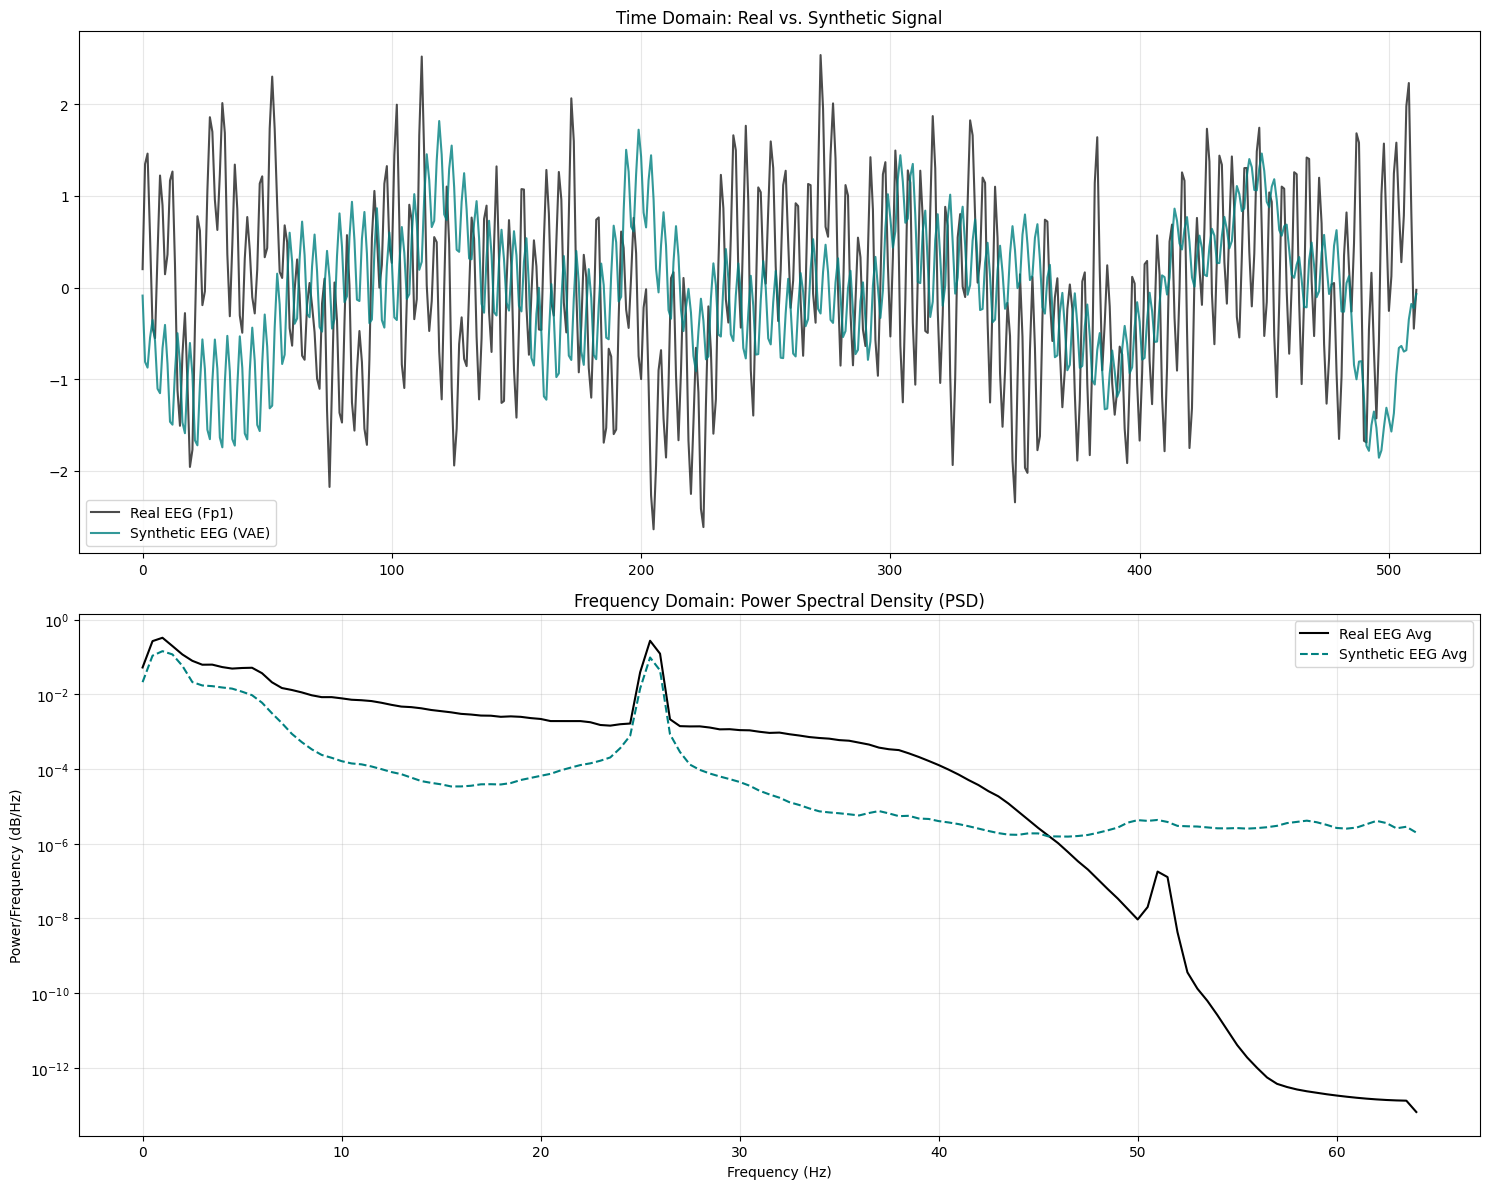

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig

def generate_and_compare(decoder_model, real_data, num_samples=5, latent_dim=16, fs=128):
    # 1. Generate Synthetic Data
    random_latent_vectors = np.random.normal(size=(num_samples, latent_dim))
    synthetic_signals = decoder_model.predict(random_latent_vectors, verbose=0)
    synthetic_signals = np.squeeze(synthetic_signals) # Shape: (num_samples, 512)

    # 2. Setup Plotting
    fig, axes = plt.subplots(2, 1, figsize=(15, 12))
    
    # --- Time Domain Comparison ---
    axes[0].plot(real_data[0, :, 0], label='Real EEG (Fp1)', color='black', alpha=0.7)
    axes[0].plot(synthetic_signals[0], label='Synthetic EEG (VAE)', color='teal', alpha=0.8)
    axes[0].set_title("Time Domain: Real vs. Synthetic Signal")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Frequency Domain Comparison (PSD) ---
    # Using Welch's method to see the brain rhythms
    freqs_real, psd_real = sig.welch(real_data.reshape(-1, 512), fs, nperseg=256)
    freqs_synth, psd_synth = sig.welch(synthetic_signals, fs, nperseg=256)
    
    axes[1].semilogy(freqs_real, np.mean(psd_real, axis=0), label='Real EEG Avg', color='black')
    axes[1].semilogy(freqs_synth, np.mean(psd_synth, axis=0), label='Synthetic EEG Avg', color='teal', linestyle='--')
    axes[1].set_title("Frequency Domain: Power Spectral Density (PSD)")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Power/Frequency (dB/Hz)")
    axes[1].legend()
    axes[1].grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Execute comparison
# X_train_norm should be (Samples, 512, 1)
generate_and_compare(decoder, X_train_norm, num_samples=len(X_train_norm), latent_dim=16)